# Multi-agent position–velocity switching linear dynamical system

A switching linear dynamical system (SLDS) combines a discrete regime $z_t$ with a continuous latent state $x_t$. Here the state contains the two-dimensional positions and velocities of six agents,

$$
x_t=
\begin{bmatrix}p_t\\v_t\end{bmatrix}
\in\mathbb{R}^{24},
$$

while the 12-dimensional observation contains positions only. This tutorial defines the complete multi-agent model, generates 50 synthetic trajectories with observed controls, applies missingness patterns taken from real position data, and measures recovery with a Rao–Blackwellized particle filter. The final recovery summary is the notebook's only plot.


## Model setup

We introduce the model in generative order, beginning with the measured data.

### 1. Observation model

Let $p_t\in\mathbb{R}^{12}$ stack the agents' two-dimensional positions, $v_t\in\mathbb{R}^{12}$ stack their velocities, $z_t\in\{0,\ldots,K-1\}$ denote the discrete regime, and $u_t\in\mathbb{R}^{d_u}$ be a known control input. We treat $u_t$ as observed rather than latent.

Only position is observed, so with $H=[I\;0]$,

$$
y_t\mid x_t,z_t
\sim
\mathcal{N}\!\left(Hx_t,R_{z_t}\right),
\qquad
x_t=\begin{bmatrix}p_t\\v_t\end{bmatrix}.
$$

The control has no direct effect on the observation once $x_t$ is given. It affects $y_t$ only indirectly through the latent dynamics. Missing observation coordinates are represented by `NaN`; the filter omits those coordinates from the measurement update while continuing to propagate position, velocity, and regime uncertainty.

### 2. Continuous latent dynamics

Using the convention that $z_t$ selects the dynamics active from $t$ to $t+1$, the multi-agent continuous-time model is

$$
\frac{d}{dt}
\begin{bmatrix}p\\v\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
0&I\\
0&G(W_{z_t})
\end{bmatrix}
}_{\widetilde A_{z_t}}
\begin{bmatrix}p\\v\end{bmatrix}
+
\underbrace{
\begin{bmatrix}0\\c_B B_{z_t}\end{bmatrix}
}_{\widetilde B_{z_t}}
u(t)
+\eta_t.
$$

Thus $\dot p=v$ and $\dot v=G(W_{z_t})v+c_BB_{z_t}u+\eta_t^v$. The identity is in the top-right block of $\widetilde A_{z_t}$ because velocity is the derivative of position. Agent interactions enter through

$$
G(W_k)=L(W_k)\otimes I_2,
$$

where $L(W_k)$ is the directed graph Laplacian for regime $k$.

For sampling and filtering at $\Delta t=1/25$ seconds, we use

$$
p_{t+1}
=p_t+\Delta t\,v_t
+\tfrac12\Delta t^2c_BB_{z_t}u_t
+\epsilon_t^p,
$$

$$
v_{t+1}
=v_t+\Delta t\,G(W_{z_t})v_t
+\Delta t\,c_BB_{z_t}u_t
+\epsilon_t^v.
$$

Equivalently,

$$
x_{t+1}\mid x_t,z_t,u_t
\sim
\mathcal{N}\!\left(A_{z_t}x_t+B^{\mathrm{disc}}_{z_t}u_t,Q_{z_t}\right).
$$

The covariance $Q_{z_t}$ uses the integrated white-acceleration form, including correlated position and velocity increments.

### 3. Switching dynamics

The regime sequence is a first-order Markov chain:

$$
z_{t+1}\mid z_t
\sim
\operatorname{Categorical}\!\left(P_{z_t,:}\right),
$$

or, componentwise,

$$
p(z_{t+1}=k\mid z_t=j)=P_{jk},
\qquad
\sum_{k=0}^{K-1}P_{jk}=1.
$$

### Initial conditions

The joint latent process needs initial distributions for both latent variables:

$$
z_0\sim\operatorname{Categorical}(\pi_0),
$$

$$
x_0\mid z_0=k
\sim
\mathcal{N}(m_{0,k},\Sigma_{0,k}).
$$

Together, these equations define the generative model for $(z_{0:T},x_{0:T},y_{0:T})$ conditional on the observed controls $u_{0:T}$.


## SLDS in Dynestyx

Dynestyx stores the joint latent state as $[z_t,x_t]$: the first scalar is the discrete regime and the remaining entries are the stacked position–velocity state. The model uses three components throughout:

- `MixedStateDistribution` for the initial joint state;
- `SwitchingLinearGaussianStateEvolution` for the Markov switch and regime-specific position–velocity dynamics;
- `SwitchingLinearGaussianObservation` for the position-only observation model.

For inference we use a Rao–Blackwellized particle filter (RBPF). It samples particles over the discrete regime history while analytically marginalizing the conditionally linear-Gaussian position–velocity state with Kalman updates.


In [ ]:
import itertools
import os
from pathlib import Path
import time

import jax
jax.config.update("jax_enable_x64", False)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from numpyro.infer.initialization import init_to_value
import optax

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel, Filter
from dynestyx.inference.configs.filter import RBPFConfig
from dynestyx.inference.integrations.cd_dynamax.discrete_filter import (
    compute_cd_dynamax_discrete_filter,
)
from dynestyx.models import (
    MixedStateDistribution,
    SwitchingLinearGaussianObservation,
    SwitchingLinearGaussianStateEvolution,
)

QUICK_MODE = os.environ.get("DYNESTYX_TUTORIAL_QUICK", "0") == "1"
DATA_DIR = Path(os.environ.get(
    "DYNESTYX_SLDS_DATA_DIR",
    "/Users/anushriarora/Desktop/collab-gerbils/analysis_outputs/"
    "slds_bouts/nan_preserving_window_8s_25hz",
))

SAMPLE_RATE_HZ = 25.0
DELTA_T = 1.0 / SAMPLE_RATE_HZ
ACCELERATION_EFFECT_SCALE = 4.0
N_AGENTS = 6
NUM_REGIMES = 2
NUM_TIMESTEPS = 75  # the observed length in 001_SLDS_model_tutorial.ipynb
POSITION_DIM = VELOCITY_DIM = OBSERVATION_DIM = 2 * N_AGENTS
STATE_DIM = POSITION_DIM + VELOCITY_DIM
N_SIMULATED_TRAJECTORIES = 4 if QUICK_MODE else 50
N_MASK_REPLICATES = 1 if QUICK_MODE else 10
N_REAL_PATTERN_REPLICATES = 1 if QUICK_MODE else 10
N_IRREGULAR_SCHEDULE_REPLICATES = 1 if QUICK_MODE else 5
SHARED_FIT_BATCH_SIZE = 1 if QUICK_MODE else 2
RANDOM_SEED = 1907
RESULTS_PATH = Path(
    "SLDS_mutli_agent_model_recovery_results_quick.npz"
    if QUICK_MODE else "SLDS_mutli_agent_model_recovery_results.npz"
)
IRREGULAR_RESULTS_PATH = Path(
    "SLDS_mutli_agent_model_irregular_recovery_results_quick.npz"
    if QUICK_MODE
    else "SLDS_mutli_agent_model_irregular_recovery_results.npz"
)
IRREGULAR_OBSERVATION_RATE_HZ = 8.0

MISSINGNESS_PERCENTAGES = np.array(
    [0.0, 50.0, 100.0] if QUICK_MODE
    else [0.0, 10.0, 20.0, 35.0, 50.0, 70.0, 85.0, 95.0, 100.0]
)
MAP_STEPS = 2 if QUICK_MODE else 80
MAP_PARTICLES = 4
IRREGULAR_MAP_STEPS = 2 if QUICK_MODE else 300
IRREGULAR_MAP_PARTICLES = 4 if QUICK_MODE else 12
IRREGULAR_LEARNING_RATE = 1e-3
IRREGULAR_GRADIENT_CLIP = 0.1
EVALUATION_PARTICLES = 8 if QUICK_MODE else 12
LEARNING_RATE = 6e-3

print("JAX devices:", jax.devices())
print("trajectory length:", NUM_TIMESTEPS)
print("shared-fit trajectories:", N_SIMULATED_TRAJECTORIES)
print("random-mask replicates:", N_MASK_REPLICATES)
print("real-pattern shared-fit replicates:", N_REAL_PATTERN_REPLICATES)
print("irregular-schedule shared-fit replicates:", N_IRREGULAR_SCHEDULE_REPLICATES)
print("saved recovery results:", RESULTS_PATH.resolve())
print("MAP steps:", MAP_STEPS)
print(
    "irregular-fit steps and particles:",
    IRREGULAR_MAP_STEPS,
    IRREGULAR_MAP_PARTICLES,
)


## Observed controls and real-data masks

The controls $u_t$ are supplied to the model. For simulation we create reproducible sparse one-hot acceleration inputs, and during filtering we condition on those same control times and values.

The real dataset is used only to determine the observation layout and provide finite/`NaN` position masks. Each real mask is copied onto a synthetic position trajectory; the corresponding latent velocities remain unobserved. Set `DYNESTYX_SLDS_DATA_DIR` to a directory containing `train.npz`, `val.npz`, and `test.npz` to reproduce the experiment elsewhere.


In [2]:
required = [DATA_DIR / f"{name}.npz" for name in ("train", "val", "test")]
missing_files = [item for item in required if not item.exists()]
if missing_files:
    raise FileNotFoundError(
        "Set DYNESTYX_SLDS_DATA_DIR to the directory containing train.npz, "
        f"val.npz, and test.npz. Missing: {missing_files}"
    )


def load_split(name):
    with np.load(DATA_DIR / f"{name}.npz", allow_pickle=False) as archive:
        raw = np.asarray(archive["obs_values"], dtype=np.float32)
        valid = np.asarray(archive["obs_valid_mask"], dtype=bool)
        if not np.array_equal(valid, np.isfinite(raw)):
            raise ValueError(f"Stored mask disagrees with NaNs in {name}")
        return {
            "raw": raw,
            "valid": valid,
            "controls": np.asarray(archive["ctrl_values"], dtype=np.float32),
            "obs_columns": archive["obs_columns"].astype(str),
            "ctrl_columns": archive["ctrl_columns"].astype(str),
            "bout_ids": archive["bout_ids"].astype(str),
            "call_composition": archive["call_composition"].astype(str),
            "dominant_call_type": archive["dominant_call_type"].astype(str),
            "dominant_call_fraction": np.asarray(
                archive["dominant_call_fraction"], dtype=float
            ),
        }


splits = {name: load_split(name) for name in ("train", "val", "test")}
train_positions = splits["train"]["raw"].reshape(-1, N_AGENTS, 2)
SHARED_XY_ORIGIN = np.nanmean(train_positions, axis=(0, 1))
SHARED_SPATIAL_SCALE = max(
    float(np.sqrt(np.nanmean((train_positions - SHARED_XY_ORIGIN) ** 2))),
    1e-6,
)
coordinate_origin = np.tile(SHARED_XY_ORIGIN, N_AGENTS)


def standardize_positions(values):
    return (np.asarray(values) - coordinate_origin) / SHARED_SPATIAL_SCALE


all_real = np.concatenate([
    standardize_positions(splits[name]["raw"][:, :NUM_TIMESTEPS])
    for name in ("train", "val", "test")
])
CONTROL_DIM = splits["train"]["controls"].shape[-1]
CONTROL_COLUMNS = splits["train"]["ctrl_columns"]
OBS_TIMES = jnp.arange(NUM_TIMESTEPS, dtype=jnp.float32) / SAMPLE_RATE_HZ
CTRL_TIMES = OBS_TIMES

print("observation dimension:", OBSERVATION_DIM)
print("control columns:", CONTROL_COLUMNS.tolist())
print("shared spatial origin:", SHARED_XY_ORIGIN.round(3))
print("shared spatial scale:", round(SHARED_SPATIAL_SCALE, 3))


# Draw 10 reproducible batches of 50 real masks. Within each batch the masks
# are sampled without replacement and assigned one-to-one to the 50 simulations.
all_valid = np.concatenate([
    splits[name]["valid"][:, :NUM_TIMESTEPS]
    for name in ("train", "val", "test")
])
if len(all_valid) < N_SIMULATED_TRAJECTORIES:
    raise ValueError(
        f"Need at least {N_SIMULATED_TRAJECTORIES} real trajectories, "
        f"but found {len(all_valid)}"
    )
mask_rng = np.random.default_rng(RANDOM_SEED + 3)
real_mask_indices = np.stack([
    mask_rng.choice(
        len(all_valid), size=N_SIMULATED_TRAJECTORIES, replace=False
    )
    for _ in range(N_REAL_PATTERN_REPLICATES)
])
real_pattern_valid_batches = all_valid[real_mask_indices]
real_pattern_missing_percent = 100.0 * (
    1.0 - real_pattern_valid_batches.mean(axis=(2, 3))
)
real_pattern_batch_missing_percent = real_pattern_missing_percent.mean(axis=1)
print(
    "mean missingness in each 50-mask batch (%):",
    np.round(real_pattern_batch_missing_percent, 1),
)


observation dimension: 12
control columns: ['alarm', 'combo', 'dfm', 'harmonic', 'low', 'mixed', 'ufm', 'warble']
shared spatial origin: [289.238 459.387]
shared spatial scale: 159.762
mean missingness in each 50-mask batch (%): [50.8 48.7 54.1 53.3 47.2 53.6 51.5 51.4 47.9 51.3]


## Initialize synthetic SLDS parameters

The transition matrix $P$ is sticky, so each regime usually persists while switching remains possible. Each regime has its own directed interaction weights $W_k$, acceleration-control scale, and integrated process covariance. The observation matrix $H=[I\;0]$ exposes all position coordinates and no velocity coordinates.

The fitted structural parameter block contains $P$ and the off-diagonal directed entries of $W$. Acceleration-control templates and process-noise scales remain fixed so that short-window nuisance-parameter confounding does not obscure recovery of the interaction structure.


In [3]:
INTERACTION_RECEIVER = jnp.asarray([
    i for i in range(N_AGENTS) for j in range(N_AGENTS) if i != j
])
INTERACTION_SENDER = jnp.asarray([
    j for i in range(N_AGENTS) for j in range(N_AGENTS) if i != j
])
N_DIRECTED_INTERACTIONS = N_AGENTS * (N_AGENTS - 1)


def interaction_weights_from_params(params):
    directed = jnp.asarray(params["W_directed"])
    W = jnp.zeros((directed.shape[0], N_AGENTS, N_AGENTS))
    return W.at[:, INTERACTION_RECEIVER, INTERACTION_SENDER].set(directed)


def velocity_drift_matrix_from_params(params):
    W = interaction_weights_from_params(params)
    laplacian = W - jnp.sum(W, axis=-1)[..., :, None] * jnp.eye(N_AGENTS)
    return jnp.einsum(
        "kij,ab->kiajb", laplacian, jnp.eye(2)
    ).reshape(NUM_REGIMES, VELOCITY_DIM, VELOCITY_DIM)


def continuous_dynamics_matrix_from_params(params):
    velocity_drift = velocity_drift_matrix_from_params(params)
    zero = jnp.zeros((NUM_REGIMES, POSITION_DIM, POSITION_DIM))
    identity = jnp.tile(jnp.eye(POSITION_DIM)[None], (NUM_REGIMES, 1, 1))
    top = jnp.concatenate([zero, identity], axis=-1)
    bottom = jnp.concatenate([zero, velocity_drift], axis=-1)
    return jnp.concatenate([top, bottom], axis=-2)


def dynamics_matrix_from_params(params):
    # Euler discretization of the continuous generator.
    return jnp.eye(STATE_DIM)[None] + DELTA_T * continuous_dynamics_matrix_from_params(params)


transition_matrix_true = jnp.array([[0.92, 0.08], [0.08, 0.92]])
initial_probs_true = jnp.array([0.50, 0.50])

W_true_dense = np.full(
    (NUM_REGIMES, N_AGENTS, N_AGENTS), 0.18, dtype=np.float32
)
for regime in range(NUM_REGIMES):
    np.fill_diagonal(W_true_dense[regime], 0.0)
for left, right in ((0, 1), (2, 3), (4, 5)):
    W_true_dense[0, left, right] = W_true_dense[0, right, left] = 1.25
for left, right in ((0, 3), (1, 4), (2, 5)):
    W_true_dense[1, left, right] = W_true_dense[1, right, left] = 1.55
W_directed_true = jnp.asarray(
    W_true_dense[:, np.asarray(INTERACTION_RECEIVER), np.asarray(INTERACTION_SENDER)]
)

parameter_rng = np.random.default_rng(RANDOM_SEED + 11)
B_regime_0 = parameter_rng.uniform(
    0.75, 1.25, size=(VELOCITY_DIM, CONTROL_DIM)
).astype(np.float32)
B_regime_1 = -np.roll(B_regime_0[:, ::-1], shift=3, axis=0)
B_templates = np.stack([B_regime_0, B_regime_1])
B_templates /= np.sqrt(np.mean(B_templates**2, axis=(1, 2), keepdims=True))
B_templates = jnp.asarray(B_templates)
B_scale_true = jnp.array([0.90, 1.20])


def acceleration_control_matrix_from_params(params):
    scale = params["B_scale"] if "B_scale" in params else B_scale_true
    return jnp.asarray(scale)[..., None, None] * B_templates


def discrete_control_matrix_from_params(params):
    acceleration_B = ACCELERATION_EFFECT_SCALE * acceleration_control_matrix_from_params(params)
    position_B = 0.5 * DELTA_T**2 * acceleration_B
    velocity_B = DELTA_T * acceleration_B
    return jnp.concatenate([position_B, velocity_B], axis=-2)


xy_acceleration_scale = np.tile(
    np.array([0.16, 0.13], dtype=np.float32), N_AGENTS
)
acceleration_scale_true = jnp.asarray(
    np.stack([xy_acceleration_scale, 1.5 * xy_acceleration_scale])
)
fixed_r_scale = jnp.full((OBSERVATION_DIM,), 0.012)
position_initial_scale = np.tile(
    np.array([1.25, 0.68], dtype=np.float32), N_AGENTS
)
velocity_initial_scale = np.tile(
    np.array([0.22, 0.15], dtype=np.float32), N_AGENTS
)
initial_scale = jnp.asarray(
    np.concatenate([position_initial_scale, velocity_initial_scale])
)

TRUE_PARAMS = {
    "transition_matrix": transition_matrix_true,
    "W_directed": W_directed_true,
    "B_scale": B_scale_true,
    "acceleration_scale": acceleration_scale_true,
}


def integrated_acceleration_covariance(acceleration_scale):
    variance = jnp.square(jnp.asarray(acceleration_scale))
    diagonal = jnp.eye(POSITION_DIM)[None] * variance[..., None]
    q_pp = (DELTA_T**3 / 3.0) * diagonal
    q_pv = (DELTA_T**2 / 2.0) * diagonal
    q_vv = DELTA_T * diagonal
    top = jnp.concatenate([q_pp, q_pv], axis=-1)
    bottom = jnp.concatenate([q_pv, q_vv], axis=-1)
    covariance = jnp.concatenate([top, bottom], axis=-2)
    return covariance + 1e-7 * jnp.eye(STATE_DIM)[None]


## Define the Dynestyx model

`MixedStateDistribution` implements the two initial-condition equations. `SwitchingLinearGaussianStateEvolution` combines the categorical transition with the regime-specific discretized position–velocity dynamics. `SwitchingLinearGaussianObservation` selects the position-only observation matrix and covariance.

The same construction is reused for simulation, shared-parameter fitting, and filtered-state evaluation.


In [4]:
def dynamical_model_from_params(params):
    acceleration_scale = (
        params["acceleration_scale"]
        if "acceleration_scale" in params
        else acceleration_scale_true
    )
    Q = integrated_acceleration_covariance(acceleration_scale)
    R = jnp.tile(
        (jnp.square(fixed_r_scale)[:, None] * jnp.eye(OBSERVATION_DIM))[None],
        (NUM_REGIMES, 1, 1),
    )
    H_single = jnp.concatenate(
        [jnp.eye(POSITION_DIM), jnp.zeros((POSITION_DIM, VELOCITY_DIM))],
        axis=-1,
    )
    H = jnp.tile(H_single[None], (NUM_REGIMES, 1, 1))
    return DynamicalModel(
        control_dim=CONTROL_DIM,
        initial_condition=MixedStateDistribution(
            categorical_probs=initial_probs_true,
            continuous_locs=jnp.zeros((NUM_REGIMES, STATE_DIM)),
            continuous_covs=jnp.tile(
                jnp.diag(jnp.square(initial_scale))[None], (NUM_REGIMES, 1, 1)
            ),
        ),
        state_evolution=SwitchingLinearGaussianStateEvolution(
            transition_matrix=jnp.asarray(params["transition_matrix"]),
            A=dynamics_matrix_from_params(params),
            B=discrete_control_matrix_from_params(params),
            bias=jnp.zeros((NUM_REGIMES, STATE_DIM)),
            cov=Q,
        ),
        observation_model=SwitchingLinearGaussianObservation(H=H, R=R),
    )


## Generate synthetic data

We use `DiscreteTimeSimulator` to generate 50 independent 75-step trajectories that share one parameter set. Sparse one-hot controls excite every control channel across the pooled data. Each simulated latent state contains both position and velocity, while the emitted observation contains position only.


In [5]:
control_rng = np.random.default_rng(RANDOM_SEED + 20)
simulated_controls = np.zeros(
    (N_SIMULATED_TRAJECTORIES, NUM_TIMESTEPS, CONTROL_DIM), dtype=np.float32
)
for trajectory in range(N_SIMULATED_TRAJECTORIES):
    event_times = np.arange(trajectory % 8, NUM_TIMESTEPS, 8)
    channels = (
        np.arange(len(event_times)) + 2 * trajectory
    ) % CONTROL_DIM
    simulated_controls[trajectory, event_times, channels] = 1.0


def simulation_model():
    with dsx.plate("trajectories", N_SIMULATED_TRAJECTORIES):
        return dsx.sample(
            "sim",
            dynamical_model_from_params(TRUE_PARAMS),
            predict_times=OBS_TIMES,
            ctrl_times=CTRL_TIMES,
            ctrl_values=jnp.asarray(simulated_controls),
        )


with DiscreteTimeSimulator():
    simulation = Predictive(
        simulation_model, num_samples=1, exclude_deterministic=False
    )(jr.PRNGKey(RANDOM_SEED + 21))

simulated_joint_states = np.asarray(simulation["sim_states"])[0, :, 0]
simulated_states = simulated_joint_states[..., 1:]
simulated_observations = np.asarray(simulation["sim_observations"])[0, :, 0]

assert simulated_observations.shape == (
    N_SIMULATED_TRAJECTORIES, NUM_TIMESTEPS, OBSERVATION_DIM
)
assert np.isfinite(simulated_observations).all()
print("simulated position observations:", simulated_observations.shape)
print("simulated latent states:", simulated_states.shape)
print("control events per channel:", simulated_controls.sum(axis=(0, 1)).astype(int))


simulated position observations: (50, 75, 12)
simulated latent states: (50, 75, 24)
control events per channel: [63 57 63 57 62 56 62 50]


## Shared MAP recovery model

One shared $(P,W)$ pair is fit across all 50 trajectories. Optimization begins in the correct broad regime-specific neighborhood but not at the generating parameters. The prior mode is deliberately displaced, so the 100% missing endpoint is a prior-only reference.

Parameter scores are invariant to the arbitrary regime labels: fitted regimes are aligned to the generating regimes before the normalized errors are computed. Full-state RMSE evaluates both position and latent velocity from the RBPF filtered means.


In [ ]:
TRANSITION_CONCENTRATION = jnp.array([[8.0, 3.0], [3.0, 8.0]])
W_PRIOR_MEDIAN = jnp.full_like(W_directed_true, 0.80)
W_PRIOR_LOG_SD = 0.55

MAP_FILTER_CONFIG = RBPFConfig(
    n_particles=MAP_PARTICLES,
    proposal="optimal",
    crn_seed=jr.PRNGKey(RANDOM_SEED + 30),
)
IRREGULAR_MAP_FILTER_CONFIG = RBPFConfig(
    n_particles=IRREGULAR_MAP_PARTICLES,
    proposal="optimal",
    crn_seed=jr.PRNGKey(RANDOM_SEED + 31),
)
EVALUATION_FILTER_CONFIG = RBPFConfig(
    n_particles=EVALUATION_PARTICLES,
    proposal="optimal",
)


def sample_map_parameters():
    return {
        "transition_matrix": numpyro.sample(
            "transition_matrix",
            dist.Dirichlet(TRANSITION_CONCENTRATION).to_event(1),
        ),
        "W_directed": numpyro.sample(
            "W_directed",
            dist.LogNormal(jnp.log(W_PRIOR_MEDIAN), W_PRIOR_LOG_SD).to_event(2),
        ),
    }


def shared_parameter_model(
    observations_for_fit,
    controls_for_fit,
    filter_config=MAP_FILTER_CONFIG,
):
    params = sample_map_parameters()
    with Filter(filter_config=filter_config):
        with dsx.plate("fit_trajectories", N_SIMULATED_TRAJECTORIES):
            return dsx.sample(
                "fit",
                dynamical_model_from_params(params),
                obs_times=OBS_TIMES,
                obs_values=observations_for_fit,
                ctrl_times=CTRL_TIMES,
                ctrl_values=controls_for_fit,
            )


def irregular_shared_parameter_model(observations_for_fit, controls_for_fit):
    return shared_parameter_model(
        observations_for_fit,
        controls_for_fit,
        filter_config=IRREGULAR_MAP_FILTER_CONFIG,
    )


INITIAL_MAP_VALUES = {
    "transition_matrix": jnp.array([[0.90, 0.10], [0.10, 0.90]]),
    "W_directed": 0.80 * W_directed_true + 0.20 * jnp.ones_like(W_directed_true),
}


def fit_shared_parameters_batched(
    observation_batches,
    control_batches,
    keys,
    model=shared_parameter_model,
    steps=MAP_STEPS,
    learning_rate=LEARNING_RATE,
    gradient_clip=1.0,
    reject_nonfinite_updates=False,
):
    # A fresh guide at each missingness level avoids cached-tracer leakage under vmap.
    guide = AutoDelta(
        model,
        init_loc_fn=init_to_value(values=INITIAL_MAP_VALUES),
    )
    optimizer = optax.chain(
        optax.clip_by_global_norm(gradient_clip),
        optax.adam(learning_rate),
    )
    if reject_nonfinite_updates:
        optimizer = optax.apply_if_finite(
            optimizer, max_consecutive_errors=10
        )
    svi = SVI(model, guide, optimizer, Trace_ELBO())

    def fit_one(key, observations, controls):
        state = svi.init(key, observations, controls)

        def update_step(_, current_state):
            updated_state, _ = svi.update(current_state, observations, controls)
            return updated_state

        state = jax.lax.fori_loop(0, steps, update_step, state)
        return guide.median(svi.get_params(state))

    return jax.vmap(fit_one)(
        keys, jnp.asarray(observation_batches), jnp.asarray(control_batches)
    )


def fit_shared_parameters_in_chunks(
    observation_batches,
    keys,
    control_batches=None,
    model=shared_parameter_model,
    steps=MAP_STEPS,
    learning_rate=LEARNING_RATE,
    gradient_clip=1.0,
    reject_nonfinite_updates=False,
    batch_size=SHARED_FIT_BATCH_SIZE,
):
    """Fit batches in small chunks to bound memory while retaining JAX batching."""
    batch_count = len(observation_batches)
    if control_batches is None:
        control_batches = np.broadcast_to(
            simulated_controls,
            (batch_count,) + simulated_controls.shape,
        )
    chunks = []
    for start in range(0, batch_count, batch_size):
        stop = min(start + batch_size, batch_count)
        chunks.append(fit_shared_parameters_batched(
            observation_batches[start:stop],
            control_batches[start:stop],
            keys[start:stop],
            model=model,
            steps=steps,
            learning_rate=learning_rate,
            gradient_clip=gradient_clip,
            reject_nonfinite_updates=reject_nonfinite_updates,
        ))
    return jax.tree.map(lambda *values: jnp.concatenate(values, axis=0), *chunks)


DIAGNOSTIC_BLOCKS = ("P", "W", "A-I")
STATE_RECOVERY_BLOCKS = ("position", "velocity", "full")
AGGREGATE_BLOCKS = ("P", "W")
REGIME_PERMUTATIONS = tuple(itertools.permutations(range(NUM_REGIMES)))


def expanded_parameter_blocks(params):
    A_value = dynamics_matrix_from_params(params)
    return {
        "P": jnp.asarray(params["transition_matrix"]),
        "W": interaction_weights_from_params(params),
        "A-I": A_value - jnp.eye(STATE_DIM)[None],
    }


TRUE_BLOCKS = expanded_parameter_blocks(TRUE_PARAMS)


def align_and_score_parameters(params):
    fitted = expanded_parameter_blocks(params)
    candidates = []
    for permutation_tuple in REGIME_PERMUTATIONS:
        permutation = jnp.asarray(permutation_tuple)
        aligned = {
            "P": fitted["P"][permutation][:, permutation],
            "W": fitted["W"][permutation],
            "A-I": fitted["A-I"][permutation],
        }
        errors = {
            name: float(
                jnp.linalg.norm(aligned[name] - TRUE_BLOCKS[name])
                / jnp.maximum(jnp.linalg.norm(TRUE_BLOCKS[name]), 1e-8)
            )
            for name in DIAGNOSTIC_BLOCKS
        }
        aggregate = float(np.sqrt(np.mean([
            errors[name] ** 2 for name in AGGREGATE_BLOCKS
        ])))
        candidates.append((aggregate, errors))
    return min(candidates, key=lambda item: item[0])


def score_parameter_batch(params_batched):
    aggregate_values, block_values = [], []
    batch_count = int(jax.tree.leaves(params_batched)[0].shape[0])
    for replicate in range(batch_count):
        params = jax.tree.map(lambda value: value[replicate], params_batched)
        aggregate, errors = align_and_score_parameters(params)
        aggregate_values.append(aggregate)
        block_values.append([errors[name] for name in DIAGNOSTIC_BLOCKS])
    return np.asarray(aggregate_values), np.asarray(block_values)


def filtered_state_rmse_batch(
    params_batched,
    observation_batches,
    key_offset,
    control_batches=None,
    state_batches=None,
    return_blocks=False,
):
    replicate_rmse = []
    batch_count = int(jax.tree.leaves(params_batched)[0].shape[0])
    if control_batches is None:
        control_batches = np.broadcast_to(
            simulated_controls,
            (batch_count,) + simulated_controls.shape,
        )
    if state_batches is None:
        state_batches = np.broadcast_to(
            simulated_states,
            (batch_count,) + simulated_states.shape,
        )
    for replicate in range(batch_count):
        params = jax.tree.map(lambda value: value[replicate], params_batched)
        trajectory_keys = jr.split(
            jr.PRNGKey(RANDOM_SEED + 4000 + 100 * key_offset + replicate),
            N_SIMULATED_TRAJECTORIES,
        )

        def filter_one(observations, controls, key):
            output = compute_cd_dynamax_discrete_filter(
                dynamical_model_from_params(params),
                EVALUATION_FILTER_CONFIG,
                key=key,
                obs_times=OBS_TIMES,
                obs_values=observations,
                ctrl_times=CTRL_TIMES,
                ctrl_values=controls,
            )
            return output["filtered_means"]

        filtered_means = jax.vmap(filter_one)(
            jnp.asarray(observation_batches[replicate]),
            jnp.asarray(control_batches[replicate]),
            trajectory_keys,
        )
        error = filtered_means - jnp.asarray(state_batches[replicate])
        block_rmse = jnp.asarray([
            jnp.sqrt(jnp.mean(jnp.square(error[..., :POSITION_DIM]))),
            jnp.sqrt(jnp.mean(jnp.square(error[..., POSITION_DIM:]))),
            jnp.sqrt(jnp.mean(jnp.square(error))),
        ])
        replicate_rmse.append(
            np.asarray(block_rmse) if return_blocks else float(block_rmse[-1])
        )
    return np.asarray(replicate_rmse)


## Recovery under uniform and real position missingness

For the recovery curves, every missingness level fits one shared $(P,W)$ pair to all 50 trajectories for each nested random-mask replicate. The 100% missing fits supply the prior-only parameter reference and open-loop state reference.

For the real-pattern analysis, each replicate samples 50 real finite/`NaN` masks without replacement and assigns them one-to-one to the 50 simulated position trajectories. One shared $(P,W)$ pair is fit to the complete masked batch. Repeating this procedure produces the values shown in the two horizontal histograms.


In [7]:
flat_size = simulated_observations[0].size
mask_rng = np.random.default_rng(RANDOM_SEED + 40)
missing_orders = np.stack([
    np.stack([
        mask_rng.permutation(flat_size)
        for _ in range(N_SIMULATED_TRAJECTORIES)
    ])
    for _ in range(N_MASK_REPLICATES)
])

parameter_errors = []
block_errors = []
state_rmse_values = []
experiment_start = time.time()

for level_index, percentage in enumerate(MISSINGNESS_PERCENTAGES):
    observation_batches = np.repeat(
        simulated_observations[None], N_MASK_REPLICATES, axis=0
    ).reshape(N_MASK_REPLICATES, N_SIMULATED_TRAJECTORIES, -1)
    number_missing = int(round(float(percentage) / 100.0 * flat_size))
    for replicate in range(N_MASK_REPLICATES):
        for trajectory in range(N_SIMULATED_TRAJECTORIES):
            observation_batches[
                replicate, trajectory,
                missing_orders[replicate, trajectory, :number_missing]
            ] = np.nan
    observation_batches = observation_batches.reshape(
        N_MASK_REPLICATES,
        N_SIMULATED_TRAJECTORIES,
        NUM_TIMESTEPS,
        OBSERVATION_DIM,
    )

    fitted = fit_shared_parameters_in_chunks(
        observation_batches,
        jr.split(
            jr.PRNGKey(RANDOM_SEED + 1000 + level_index), N_MASK_REPLICATES
        ),
    )
    aggregate, blocks = score_parameter_batch(fitted)
    state_rmse = filtered_state_rmse_batch(
        fitted, observation_batches, key_offset=level_index
    )
    parameter_errors.append(aggregate)
    block_errors.append(blocks)
    state_rmse_values.append(state_rmse)
    print(
        f"missing {percentage:5.1f}%: parameter error={aggregate.mean():.3f}, "
        f"state RMSE={state_rmse.mean():.3f}"
    )

parameter_errors = np.stack(parameter_errors, axis=1)
block_errors = np.stack(block_errors, axis=1)
state_rmse_values = np.stack(state_rmse_values, axis=1)

assert np.isfinite(parameter_errors).all()
assert np.isfinite(block_errors).all()
assert np.isfinite(state_rmse_values).all()
assert MISSINGNESS_PERCENTAGES[-1] == 100.0


# Ten shared fits, each across 50 simulations with a fresh batch of real masks.
real_pattern_observation_batches = np.where(
    real_pattern_valid_batches,
    simulated_observations[None],
    np.nan,
)
assert np.array_equal(
    np.isnan(real_pattern_observation_batches), ~real_pattern_valid_batches
)
real_pattern_fitted = fit_shared_parameters_in_chunks(
    real_pattern_observation_batches,
    jr.split(jr.PRNGKey(RANDOM_SEED + 5000), N_REAL_PATTERN_REPLICATES),
)
real_pattern_parameter_errors, real_pattern_block_errors = score_parameter_batch(
    real_pattern_fitted
)
real_pattern_state_rmse = filtered_state_rmse_batch(
    real_pattern_fitted,
    real_pattern_observation_batches,
    key_offset=100,
)

for values in (real_pattern_parameter_errors, real_pattern_state_rmse):
    assert np.isfinite(values).all()
print(
    "real-pattern shared-fit parameter error: mean="
    f"{real_pattern_parameter_errors.mean():.3f}, "
    f"range=({real_pattern_parameter_errors.min():.3f}, "
    f"{real_pattern_parameter_errors.max():.3f})"
)
print(
    "real-pattern shared-fit state RMSE: mean="
    f"{real_pattern_state_rmse.mean():.3f}, "
    f"range=({real_pattern_state_rmse.min():.3f}, "
    f"{real_pattern_state_rmse.max():.3f})"
)

elapsed_minutes = (time.time() - experiment_start) / 60.0
np.savez_compressed(
    RESULTS_PATH,
    missingness_percentages=MISSINGNESS_PERCENTAGES,
    parameter_errors=parameter_errors,
    block_errors=block_errors,
    state_rmse_values=state_rmse_values,
    real_pattern_parameter_errors=real_pattern_parameter_errors,
    real_pattern_block_errors=real_pattern_block_errors,
    real_pattern_state_rmse=real_pattern_state_rmse,
    real_pattern_missing_percent=real_pattern_missing_percent,
    real_pattern_batch_missing_percent=real_pattern_batch_missing_percent,
    real_mask_indices=real_mask_indices,
    diagnostic_blocks=np.asarray(DIAGNOSTIC_BLOCKS),
    n_simulated_trajectories=np.asarray(N_SIMULATED_TRAJECTORIES),
    n_mask_replicates=np.asarray(N_MASK_REPLICATES),
    n_real_pattern_replicates=np.asarray(N_REAL_PATTERN_REPLICATES),
    num_timesteps=np.asarray(NUM_TIMESTEPS),
    random_seed=np.asarray(RANDOM_SEED),
    elapsed_minutes=np.asarray(elapsed_minutes),
)
print(f"Recovery experiments finished in {elapsed_minutes:.1f} minutes")
print(f"Saved reusable numerical results to {RESULTS_PATH.resolve()}")


missing   0.0%: parameter error=0.240, state RMSE=0.071


missing  10.0%: parameter error=0.248, state RMSE=0.080


missing  20.0%: parameter error=0.249, state RMSE=0.090


missing  35.0%: parameter error=0.251, state RMSE=0.106


missing  50.0%: parameter error=0.255, state RMSE=0.127


missing  70.0%: parameter error=0.258, state RMSE=0.176


missing  85.0%: parameter error=0.268, state RMSE=0.263


missing  95.0%: parameter error=0.289, state RMSE=0.486


missing 100.0%: parameter error=0.468, state RMSE=1.154


real-pattern shared-fit parameter error: mean=0.297, range=(0.281, 0.310)
real-pattern shared-fit state RMSE: mean=0.625, range=(0.525, 0.701)
Recovery experiments finished in 52.0 minutes
Saved reusable numerical results to /Users/anushriarora/Desktop/dynestyx/docs/tutorials/gentle_intro/SLDS_mutli_agent_model_recovery_results.npz


## Missingness recovery under real-data masks

The red curve summarizes normalized recovery error for the fitted transition and interaction parameters as uniformly random position entries are removed. The green curve reports full-state RMSE, including both observed positions and latent velocities. Faint lines are mask replicates, thick lines are their means, shaded bands show one standard deviation, and dashed lines mark the 100% missing references.

The neighboring histograms use the same vertical metrics. Each histogram value comes from one shared fit after a fresh batch of 50 real position-missingness patterns is copied onto the 50 simulations.


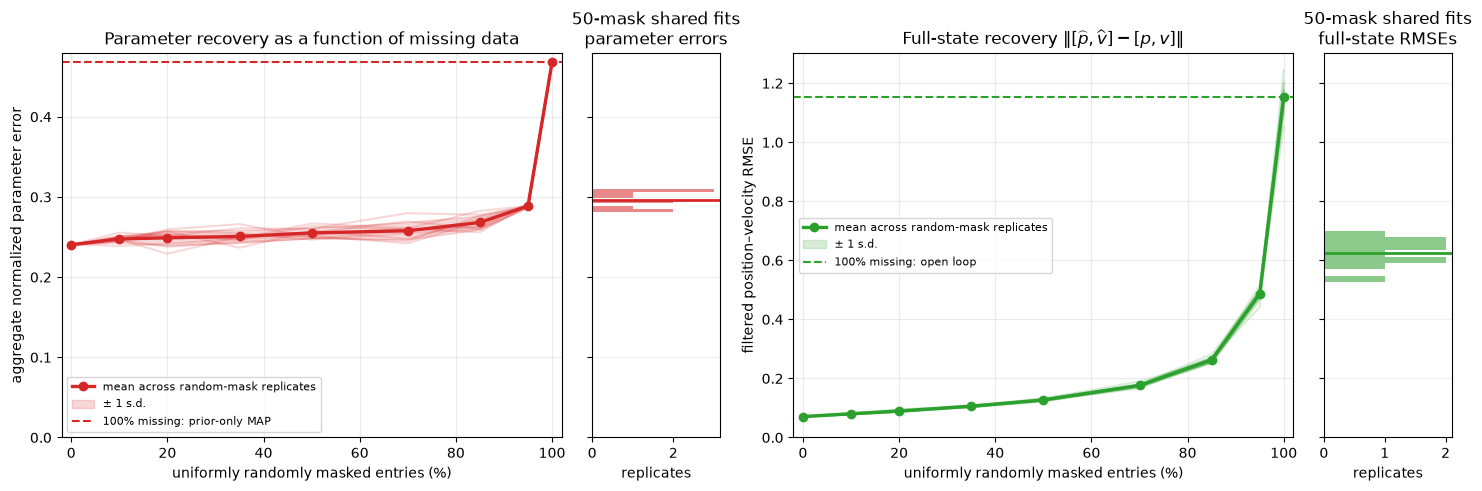

In [8]:
# This plotting cell can be rerun independently without repeating the fits.
with np.load(RESULTS_PATH, allow_pickle=False) as saved_results:
    MISSINGNESS_PERCENTAGES = saved_results["missingness_percentages"]
    parameter_errors = saved_results["parameter_errors"]
    block_errors = saved_results["block_errors"]
    state_rmse_values = saved_results["state_rmse_values"]
    real_pattern_parameter_errors = saved_results[
        "real_pattern_parameter_errors"
    ]
    real_pattern_state_rmse = saved_results["real_pattern_state_rmse"]
    real_pattern_missing_percent = saved_results[
        "real_pattern_missing_percent"
    ]
    real_pattern_batch_missing_percent = saved_results[
        "real_pattern_batch_missing_percent"
    ]

def plot_recovery(axis, values, color, ylabel, title, reference_label):
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    for replicate_values in values:
        axis.plot(
            MISSINGNESS_PERCENTAGES, replicate_values, color=color, alpha=.18
        )
    axis.plot(
        MISSINGNESS_PERCENTAGES, mean, color=color, marker="o", lw=2.4,
        label="mean across random-mask replicates",
    )
    axis.fill_between(
        MISSINGNESS_PERCENTAGES,
        np.maximum(mean - std, 0),
        mean + std,
        color=color,
        alpha=.18,
        label=r"$\pm$ 1 s.d.",
    )
    axis.axhline(mean[-1], color=color, linestyle="--", label=reference_label)
    axis.set(
        xlabel="uniformly randomly masked entries (%)",
        ylabel=ylabel,
        title=title,
        xlim=(-2, 102),
        ylim=(0, None),
    )
    axis.grid(alpha=.25)
    axis.legend(fontsize=8)



fig = plt.figure(figsize=(14.5, 4.8), constrained_layout=True)
grid = fig.add_gridspec(1, 4, width_ratios=(4.5, 1.15, 4.5, 1.15), wspace=.06)
parameter_axis = fig.add_subplot(grid[0, 0])
parameter_histogram_axis = fig.add_subplot(grid[0, 1], sharey=parameter_axis)
state_axis = fig.add_subplot(grid[0, 2])
state_histogram_axis = fig.add_subplot(grid[0, 3], sharey=state_axis)

plot_recovery(
    parameter_axis, parameter_errors, "C3", "aggregate normalized parameter error",
    "Parameter recovery as a function of missing data",
    "100% missing: prior-only MAP",
)
plot_recovery(
    state_axis, state_rmse_values, "C2", "filtered position–velocity RMSE",
    r"Full-state recovery $\|[\widehat p,\widehat v]-[p,v]\|$",
    "100% missing: open loop",
)

for histogram_axis, values, color, title in (
    (
        parameter_histogram_axis,
        real_pattern_parameter_errors,
        "C3",
        "50-mask shared fits\nparameter errors",
    ),
    (
        state_histogram_axis,
        real_pattern_state_rmse,
        "C2",
        "50-mask shared fits\nfull-state RMSEs",
    ),
):
    histogram_axis.hist(
        values,
        bins=max(4, min(8, len(values))),
        orientation="horizontal",
        color=color,
        alpha=.55,
    )
    histogram_axis.axhline(np.mean(values), color=color, lw=2)
    histogram_axis.set(xlabel="replicates", title=title)
    histogram_axis.tick_params(labelleft=False)
    histogram_axis.grid(axis="y", alpha=.2)

plt.show()


## Recovery from irregularly sampled positions and controls

The latent SLDS remains on the 25 Hz grid, but positions and controls are acquired together at event times. We draw acquisition events with

$$
q=1-\exp(-\lambda\Delta t),
$$

the grid probability implied by a Poisson rate $\lambda$. The observed control is held until the next event. At intervening times the position row is missing, so the RBPF propagates the latent state without a measurement update. This recovery fit uses 12 RBPF particles, 300 optimization steps, and a conservative irregular-fit learning rate. Five batches, each containing 50 independently drawn schedules, measure how much recovery varies with the realized acquisition times; they do not represent posterior uncertainty.


In [ ]:
irregular_rng = np.random.default_rng(RANDOM_SEED + 60)
event_probability = 1.0 - np.exp(
    -IRREGULAR_OBSERVATION_RATE_HZ * DELTA_T
)
irregular_event_masks = irregular_rng.random((
    N_IRREGULAR_SCHEDULE_REPLICATES,
    N_SIMULATED_TRAJECTORIES,
    NUM_TIMESTEPS,
)) < event_probability
irregular_event_masks[..., 0] = True
irregular_event_masks[..., -1] = True

# Controls are acquired with position and held constant until the next event.
irregular_control_batches = np.zeros((
    N_IRREGULAR_SCHEDULE_REPLICATES,
    N_SIMULATED_TRAJECTORIES,
    NUM_TIMESTEPS,
    CONTROL_DIM,
), dtype=np.float32)
for replicate in range(N_IRREGULAR_SCHEDULE_REPLICATES):
    for trajectory in range(N_SIMULATED_TRAJECTORIES):
        held_control = np.zeros(CONTROL_DIM, dtype=np.float32)
        event_number = 0
        for step in range(NUM_TIMESTEPS):
            if irregular_event_masks[replicate, trajectory, step]:
                held_control = np.zeros(CONTROL_DIM, dtype=np.float32)
                if event_number % 3 != 2:
                    channel = (
                        event_number + 2 * trajectory + replicate
                    ) % CONTROL_DIM
                    held_control[channel] = 0.35
                event_number += 1
            irregular_control_batches[
                replicate, trajectory, step
            ] = held_control


def simulate_irregular_batch(replicate):
    controls = jnp.asarray(irregular_control_batches[replicate])

    def model():
        with dsx.plate("irregular_trajectories", N_SIMULATED_TRAJECTORIES):
            return dsx.sample(
                "irregular_sim",
                dynamical_model_from_params(TRUE_PARAMS),
                predict_times=OBS_TIMES,
                ctrl_times=CTRL_TIMES,
                ctrl_values=controls,
            )

    with DiscreteTimeSimulator():
        draws = Predictive(
            model, num_samples=1, exclude_deterministic=False
        )(jr.PRNGKey(RANDOM_SEED + 70 + replicate))
    joint_states = np.asarray(draws["irregular_sim_states"])[0, :, 0]
    observations = np.asarray(draws["irregular_sim_observations"])[0, :, 0]
    return joint_states[..., 1:], observations


irregular_state_batches, irregular_complete_observation_batches = zip(*[
    simulate_irregular_batch(replicate)
    for replicate in range(N_IRREGULAR_SCHEDULE_REPLICATES)
])
irregular_state_batches = np.stack(irregular_state_batches)
irregular_complete_observation_batches = np.stack(
    irregular_complete_observation_batches
)
irregular_observation_batches = np.where(
    irregular_event_masks[..., None],
    irregular_complete_observation_batches,
    np.nan,
)

irregular_fitted = fit_shared_parameters_in_chunks(
    irregular_observation_batches,
    jr.split(
        jr.PRNGKey(RANDOM_SEED + 80),
        N_IRREGULAR_SCHEDULE_REPLICATES,
    ),
    control_batches=irregular_control_batches,
    model=irregular_shared_parameter_model,
    steps=IRREGULAR_MAP_STEPS,
    learning_rate=IRREGULAR_LEARNING_RATE,
    gradient_clip=IRREGULAR_GRADIENT_CLIP,
    reject_nonfinite_updates=True,
    batch_size=1,
)
irregular_parameter_errors, irregular_block_errors = score_parameter_batch(
    irregular_fitted
)
irregular_state_block_rmse = filtered_state_rmse_batch(
    irregular_fitted,
    irregular_observation_batches,
    key_offset=200,
    control_batches=irregular_control_batches,
    state_batches=irregular_state_batches,
    return_blocks=True,
)
irregular_state_rmse = irregular_state_block_rmse[
    :, STATE_RECOVERY_BLOCKS.index("full")
]
irregular_observed_fraction = irregular_event_masks.mean(axis=(1, 2))

for values in (irregular_parameter_errors, irregular_state_rmse):
    assert np.isfinite(values).all()
assert np.array_equal(
    np.isnan(irregular_observation_batches),
    np.broadcast_to(
        ~irregular_event_masks[..., None],
        irregular_observation_batches.shape,
    ),
)

np.savez_compressed(
    IRREGULAR_RESULTS_PATH,
    event_masks=irregular_event_masks,
    parameter_errors=irregular_parameter_errors,
    block_errors=irregular_block_errors,
    state_rmse=irregular_state_rmse,
    state_block_rmse=irregular_state_block_rmse,
    state_recovery_blocks=np.asarray(STATE_RECOVERY_BLOCKS),
    observed_fraction=irregular_observed_fraction,
    observation_rate_hz=np.asarray(IRREGULAR_OBSERVATION_RATE_HZ),
    diagnostic_blocks=np.asarray(DIAGNOSTIC_BLOCKS),
    n_schedule_replicates=np.asarray(N_IRREGULAR_SCHEDULE_REPLICATES),
    random_seed=np.asarray(RANDOM_SEED),
)

print(
    "mean acquired time points (%):",
    round(100.0 * float(irregular_observed_fraction.mean()), 1),
)
print(
    "irregular-schedule parameter error: mean=",
    round(float(irregular_parameter_errors.mean()), 3),
)
print(
    "irregular-schedule full-state RMSE: mean=",
    round(float(irregular_state_rmse.mean()), 3),
)


The event raster confirms that positions and controls share the same irregular acquisition times. Recovery errors across schedule batches summarize sensitivity to which time points were acquired.


In [ ]:
# This plotting cell can be rerun independently without repeating the fits.
with np.load(IRREGULAR_RESULTS_PATH, allow_pickle=False) as saved_irregular:
    irregular_event_masks = saved_irregular["event_masks"]
    irregular_block_errors = saved_irregular["block_errors"]
    irregular_state_block_rmse = saved_irregular["state_block_rmse"]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), constrained_layout=True)

shown_trajectories = min(12, N_SIMULATED_TRAJECTORIES)
for trajectory in range(shown_trajectories):
    event_times = np.asarray(OBS_TIMES)[
        irregular_event_masks[0, trajectory]
    ]
    axes[0].scatter(
        event_times,
        np.full(len(event_times), trajectory),
        marker="|",
        s=75,
        color="C0",
    )
axes[0].set(
    xlabel="time (s)",
    ylabel="trajectory",
    title=r"Shared $p(t_i)$ and $u(t_i)$ events",
)

parameter_mean = irregular_block_errors.mean(axis=0)
parameter_std = irregular_block_errors.std(axis=0, ddof=1)
parameter_axis = np.arange(len(DIAGNOSTIC_BLOCKS))
axes[1].bar(
    parameter_axis,
    parameter_mean,
    yerr=parameter_std,
    capsize=5,
    color=("C4", "C3", "C1"),
    alpha=.8,
)
axes[1].set(
    ylabel="normalized parameter error",
    title=r"Parameter recovery (mean $\pm$ s.d.)",
    xticks=parameter_axis,
    xticklabels=("$P$", "$W$", "$A-I$"),
    ylim=(0, None),
)

state_mean = irregular_state_block_rmse.mean(axis=0)
state_std = irregular_state_block_rmse.std(axis=0, ddof=1)
state_axis = np.arange(len(STATE_RECOVERY_BLOCKS))
axes[2].bar(
    state_axis,
    state_mean,
    yerr=state_std,
    capsize=5,
    color=("C0", "C2", "C5"),
    alpha=.8,
)
axes[2].set(
    ylabel="filtered-state RMSE",
    title=r"State recovery (mean $\pm$ s.d.)",
    xticks=state_axis,
    xticklabels=("position", "velocity", "full"),
    ylim=(0, None),
)

for axis in axes:
    axis.grid(axis="y", alpha=.25)

plt.show()


## Interpretation

Parameter recovery is comparatively stable while substantial position information remains, then approaches the prior-only MAP error at 100% missingness. Full-state error rises more sharply because velocity is never observed directly and must be inferred through the dynamics; with no position observations, filtering is entirely open loop.

The side histograms summarize repeated shared fits under batches of masks sampled from the real dataset. Their spread reflects variation in which real missingness patterns are assigned to the synthetic trajectories, along with finite-step optimization and particle-filter uncertainty.

Under irregular paired position–control acquisition, the RBPF continues to propagate on the latent grid between events. The similar recovery errors across independently sampled schedule batches show that the result is not tied to one favorable acquisition pattern.
